[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/uncertainty_attribution_shap.ipynb)

# Attributing prediction uncertainty with SHAP, on data where the answer is known

Prediction intervals vary in width from row to row, and the obvious next question is which features
make a row uncertain. There is no library for that. The common recipe is to take the width as a
target, fit a second model to it, and read that model's SHAP values.

This notebook runs the recipe on data built so the correct answer is known in advance, and puts it
next to three other quantities you can attribute the same way: CatBoost's data and knowledge
uncertainty on their own, and the distance from a row to the nearest training row.

It then withholds the driver of the spread from the model, which is the case practitioners actually
meet most often and the one the first sections cannot reach.

Runtime is about three minutes on a laptop CPU and longer on a free Colab runtime.

In [1]:
try:
    import catboost, shap
except ImportError:
    !pip install -q catboost shap

In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors

## The design

Six features on the unit interval, each with one job.

`x_mean1` and `x_mean2` drive the mean and nothing else. `x_noise` drives the spread, so the noise
grows with it. `x_gap` enters the mean too, but a slice of its range is cut out of the training data
and left in the test data, which makes it the one feature the model is missing information about. `x_dup` is a noisy copy of `x_noise` that enters the target nowhere. `x_inert`
enters nothing at all.

So the honest answer to "where does the uncertainty come from" is `x_noise` for the part that is
irreducible and `x_gap` for the part that more data would fix. `x_dup` is there because SHAP with
correlated features is known to spread credit between them, and this measures how much.

In [3]:
N_TRAIN, N_TEST, N_SEEDS = 8000, 4000, 12
SEEDS = range(N_SEEDS)
GAP = (0.40, 0.60)
Z90 = 1.645
KEEP = [0.0, 0.05, 0.15, 0.40, 1.0]
REFERENCE = "true noise function"
WIDTH = "interval width"
NOTHING = "nothing hidden"
HIDE = {"x_noise hidden, its copy kept": ["x_noise"],
        "both hidden, no proxy left": ["x_noise", "x_dup"]}
FEATURES = ["x_mean1", "x_mean2", "x_noise", "x_dup", "x_gap", "x_inert"]
ROLE = {"x_mean1": "drives the mean", "x_mean2": "drives the mean",
        "x_noise": "drives the spread", "x_dup": "noisy copy of x_noise, enters nothing",
        "x_gap": f"drives the mean, hole at {GAP[0]}-{GAP[1]}",
        "x_inert": "enters nothing"}


def mean_of(x):
    return 10 * np.sin(np.pi * x.x_mean1 * x.x_mean2) + 8 * np.sin(4 * np.pi * x.x_gap)


def sample(n, rng, keep):
    # keep is the share of the hole's rows left in training; 0.0 cuts it out entirely
    x = pd.DataFrame(rng.uniform(size=(n, len(FEATURES))), columns=FEATURES)
    x["x_dup"] = np.clip(x["x_noise"] + rng.normal(0, 0.05, n), 0, 1)
    inside = x["x_gap"].between(*GAP)
    if keep == 0.0:
        x = x[~inside].reset_index(drop=True)
    elif keep < 1.0:
        x = x[~inside | (np.arange(len(x)) % 100 < keep * 100)].reset_index(drop=True)
    sigma = 0.5 + 6 * x.x_noise ** 2
    return x, mean_of(x) + sigma * rng.normal(size=len(x)), sigma


# one place, so both runs below are guaranteed the same rows for a given seed
def train_test(seed, keep=0.0):
    rng = np.random.default_rng(seed)
    Xtr, ytr, _ = sample(N_TRAIN, rng, keep)
    Xte, _, sigma = sample(N_TEST, rng, 1.0)
    return Xtr, ytr, Xte, sigma


Xtr, _, Xte, _ = train_test(0)
print(f"{len(Xtr):,} training rows left of {N_TRAIN:,} once the hole is cut out, "
      f"{len(Xte):,} test rows")
print(f"correlation between x_noise and its copy x_dup: {Xte.x_noise.corr(Xte.x_dup):.3f}")
pd.DataFrame([{"feature": f, "role": ROLE[f]} for f in FEATURES])

6,395 training rows left of 8,000 once the hole is cut out, 4,000 test rows
correlation between x_noise and its copy x_dup: 0.985


,feature,role
0,x_mean1,drives the mean
1,x_mean2,drives the mean
2,x_noise,drives the spread
3,x_dup,"noisy copy of x_noise, enters nothing"
4,x_gap,"drives the mean, hole at 0.4-0.6"
5,x_inert,enters nothing


## The recipe

`surrogate` is the whole method: fit a model to the quantity you want explained, then average the
absolute SHAP value of each feature and report it as a share of the total.

In [4]:
def surrogate(X, target, seed):
    m = CatBoostRegressor(iterations=400, learning_rate=0.08, depth=6, random_seed=seed,
                          verbose=0, allow_writing_files=False).fit(X, target)
    v = np.abs(shap.TreeExplainer(m).shap_values(X)).mean(axis=0)
    return pd.Series(100 * v / v.sum(), index=X.columns)


def fit_uncertainty(Xtr, ytr, Xte, seed):
    m = CatBoostRegressor(loss_function="RMSEWithUncertainty", posterior_sampling=True,
                          iterations=1000, learning_rate=0.1, depth=6, random_seed=seed,
                          verbose=0, allow_writing_files=False).fit(Xtr, ytr)
    return m.virtual_ensembles_predict(Xte, prediction_type="TotalUncertainty",
                                       virtual_ensembles_count=10)


# how much the width varies, and whether that variation tracks the real noise
def signal(out, width, dist, sigma, error):
    return {"mean error": error.mean(), "width mean": width.mean(), "width sd": width.std(),
            "data over knowledge variance": (out[:, 2] / out[:, 1]).mean(),
            "width vs true sigma": spearmanr(width, sigma).statistic,
            "distance vs true sigma": spearmanr(dist, sigma).statistic}

## The run

One `RMSEWithUncertainty` model per seed. `virtual_ensembles_predict` returns the mean, the
knowledge variance and the data variance; both are variances, so they are square-rooted before use,
and the interval width is `2 * Z90 * sqrt(knowledge + data)`, with `Z90` the two-sided 90% normal
quantile.

Five quantities get attributed per seed. The true noise function is included as a reference: it is
the one target whose correct attribution is not in dispute.

The same loop records how the model behaves inside the hole against outside it, which is what makes
`x_gap` worth finding at all.

In [5]:
attr_rows, gap_rows, signal_rows = [], [], []
for s in SEEDS:
    Xtr, ytr, Xte, sigma = train_test(s)
    out = fit_uncertainty(Xtr, ytr, Xte, s)
    knowledge, data = np.sqrt(out[:, 1]), np.sqrt(out[:, 2])
    width = 2 * Z90 * np.sqrt(out[:, 1] + out[:, 2])
    dist = NearestNeighbors(n_neighbors=1).fit(Xtr).kneighbors(Xte)[0][:, 0]

    # error against the noiseless mean, so the irreducible part does not mask the hole
    error = np.abs(mean_of(Xte).values - out[:, 0])
    inside = Xte.x_gap.between(*GAP).values
    for label, v in (("error vs the noiseless mean", error), ("knowledge uncertainty", knowledge),
                     ("data uncertainty", data), ("distance to training data", dist)):
        gap_rows.append({"quantity": label, "seed": s,
                         "in the hole": v[inside].mean(), "outside": v[~inside].mean()})

    signal_rows.append({"hidden": NOTHING, "seed": s,
                        **signal(out, width, dist, sigma, error)})
    for label, target in ((REFERENCE, sigma.values), (WIDTH, width),
                          ("data uncertainty", data), ("knowledge uncertainty", knowledge),
                          ("distance to training data", dist)):
        attr_rows.append({"target": label, "seed": s, **surrogate(Xte, target, s).to_dict()})
    print(f"seed {s} done", flush=True)

attr_df, gap_df = pd.DataFrame(attr_rows), pd.DataFrame(gap_rows)

seed 0 done


seed 1 done


seed 2 done


seed 3 done


seed 4 done


...

seed 7 done


seed 8 done


seed 9 done


seed 10 done


seed 11 done


## Does the hole matter

Before reading any attribution, check that there is something to attribute.

In [6]:
gap = gap_df.groupby("quantity", sort=False)[["in the hole", "outside"]].mean()
gap["ratio"] = gap["in the hole"] / gap["outside"]
per_seed = gap_df["in the hole"] / gap_df["outside"]
gap["ratio sd"] = per_seed.groupby(gap_df["quantity"], sort=False).std()
gap.round(2)

,in the hole,outside,ratio,ratio sd
quantity,,,,
error vs the noiseless mean,5.35,0.73,7.29,1.13
knowledge uncertainty,0.16,0.10,1.57,0.46
data uncertainty,2.82,1.51,1.87,0.36
distance to training data,0.17,0.13,1.27,0.01


The error column is the one that moves: inside the hole the model is several times more wrong than
outside it. None of the three quantities the model or the training set reports comes anywhere near
matching that rise, and the nearest-neighbour distance barely moves at all, because five of the six
dimensions are untouched by the hole and they dominate the distance.

What matters for attribution is not the size of that rise but whether the right feature drives it,
which is what the next cell measures.

## What the attribution says

In [7]:
share = attr_df.groupby("target", sort=False)[FEATURES].mean()
print(f"share of total |SHAP|, %, mean over {N_SEEDS} seeds")
print(share.round(1).to_string())
print()
print("standard deviation across seeds:")
print(attr_df.groupby("target", sort=False)[FEATURES].std().round(1).to_string())
print()
print(f"attributing the {REFERENCE}, where the right answer is not in doubt, still sent "
      f"{share.loc[REFERENCE, 'x_dup']:.0f}% of the credit to x_dup, which enters the target "
      f"nowhere")
print(f"the {WIDTH} and data uncertainty rows differ by at most "
      f"{(share.loc[WIDTH] - share.loc['data uncertainty']).abs().max():.1f} points")

share of total |SHAP|, %, mean over 12 seeds
                           x_mean1  x_mean2  x_noise  x_dup  x_gap  x_inert
target                                                                     
true noise function            0.1      0.1     73.8   25.7    0.1      0.1
interval width                 7.6      7.5     35.3   13.3   28.8      7.6
data uncertainty               7.6      7.5     35.5   13.1   28.7      7.6
knowledge uncertainty          8.6      9.2     36.2   16.5   21.8      7.7
distance to training data     10.9     11.1      9.7    9.4   48.0     10.9

standard deviation across seeds:
                           x_mean1  x_mean2  x_noise  x_dup  x_gap  x_inert
target                                                                     
true noise function            0.0      0.1      3.6    3.5    0.1      0.1
interval width                 1.1      1.5      6.2    2.6    8.5      0.9
data uncertainty               1.1      1.5      5.9    2.8    8.4      0.9
knowledge

In [8]:
print(f"where x_gap ranked among the six features over {N_SEEDS} seeds, "
      "and which feature took first place:")
for t in [t for t in share.index if t != REFERENCE]:
    sub = attr_df[attr_df.target == t][FEATURES]
    r = sub.rank(axis=1, ascending=False)["x_gap"].value_counts().sort_index()
    above = (sub.gt(sub["x_gap"], axis=0).sum()
             .drop("x_gap").pipe(lambda z: z[z > 0]).sort_values(ascending=False))
    print(f"  {t}")
    print("      x_gap: " + ", ".join(f"rank {int(k)} on {v}" for k, v in r.items()))
    print("      outranked by: " + (", ".join(f"{k} on {v}" for k, v in above.items())
                                    or "nothing"))

where x_gap ranked among the six features over 12 seeds, and which feature took first place:
  interval width
      x_gap: rank 1 on 5, rank 2 on 5, rank 3 on 2
      outranked by: x_noise on 7, x_dup on 2
  data uncertainty
      x_gap: rank 1 on 4, rank 2 on 6, rank 3 on 2
      outranked by: x_noise on 8, x_dup on 2
  knowledge uncertainty
      x_gap: rank 1 on 3, rank 2 on 4, rank 3 on 5
      outranked by: x_noise on 9, x_dup on 5
  distance to training data
      x_gap: rank 1 on 12
      outranked by: nothing


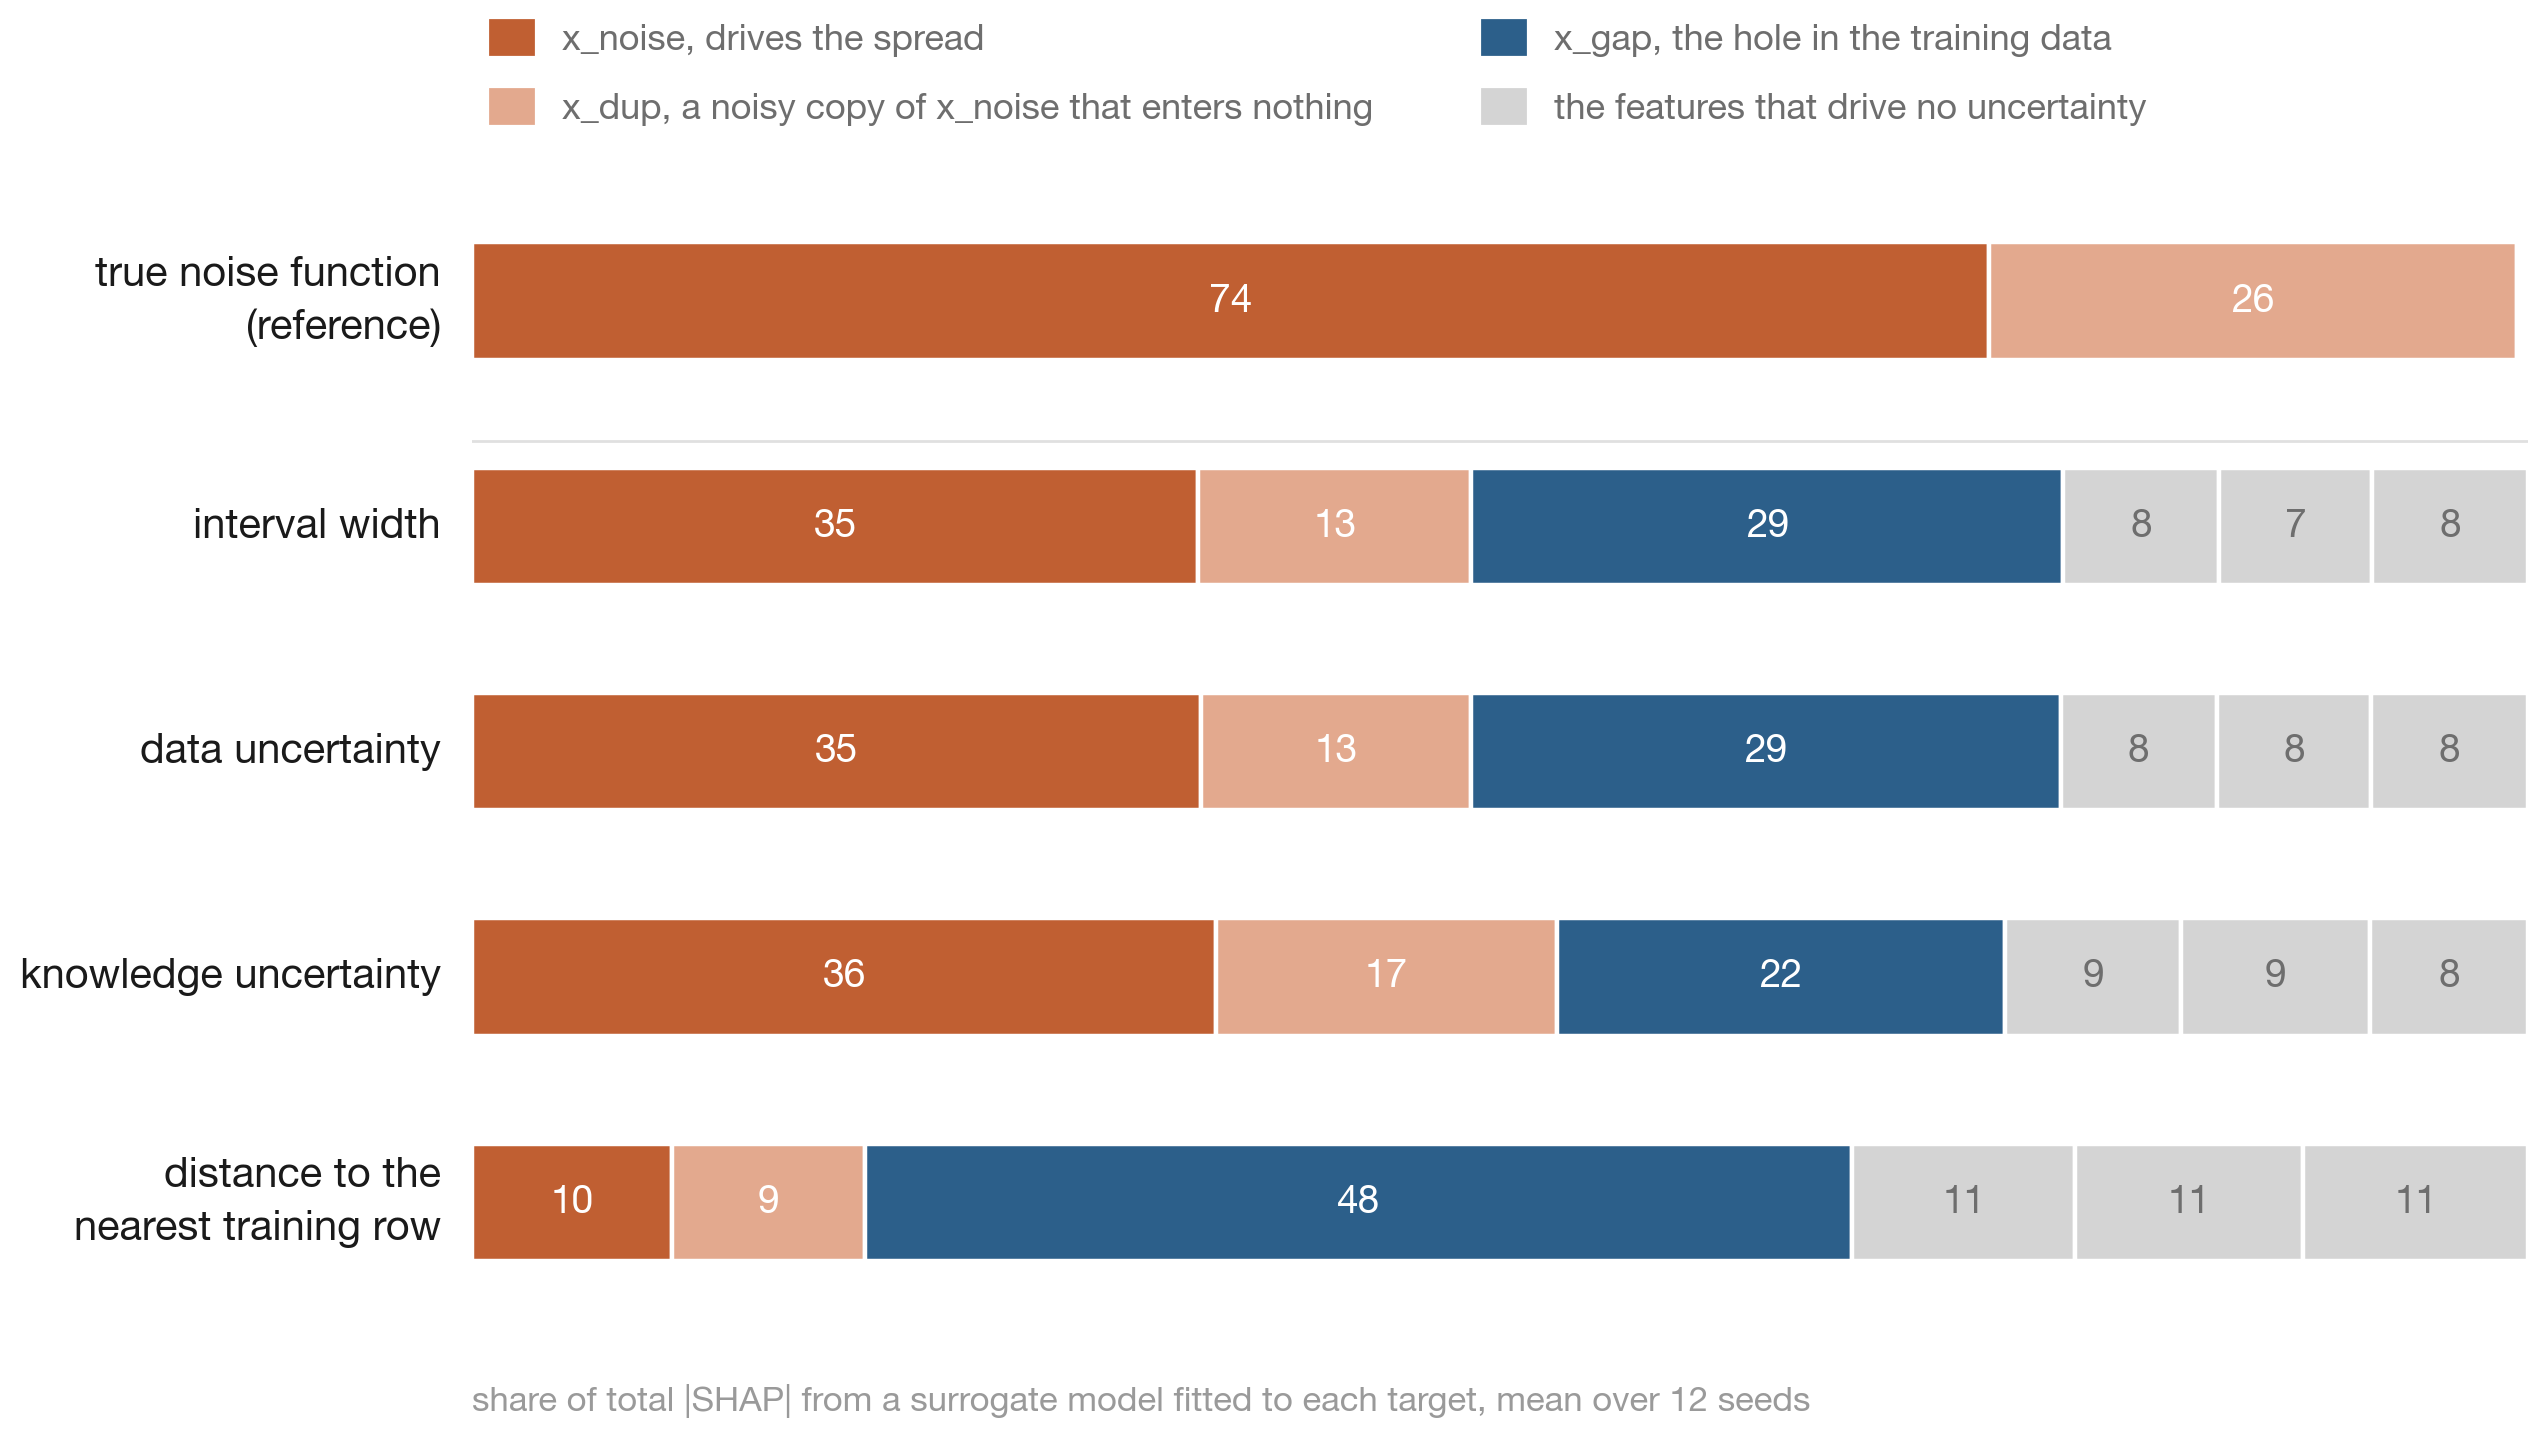

In [9]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_E, CORAL_E, TWIN_E, GREY_E = "#2C5F8A", "#C05F32", "#E3A98E", "#d4d4d4"
INK, TEXT_MUTED, TEXT_FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"

COLOUR = {"x_noise": CORAL_E, "x_dup": TWIN_E, "x_gap": BLUE_E}
PLAIN = [f for f in FEATURES if f not in COLOUR]
ORDER = list(COLOUR) + PLAIN
LEGEND = [(CORAL_E, "x_noise, drives the spread"),
          (TWIN_E, "x_dup, a noisy copy of x_noise that enters nothing"),
          (BLUE_E, "x_gap, the hole in the training data"),
          (GREY_E, "the features that drive no uncertainty")]
LABEL = {REFERENCE: f"{REFERENCE}\n(reference)",
         "distance to training data": "distance to the\nnearest training row"}

fig = plt.figure(figsize=(13.8, 8.6), dpi=200)
ax = fig.add_axes([0.235, 0.095, 0.745, 0.655])
ax.set_xlim(0, 100)
ax.set_ylim(len(share) - 0.5, -0.5)
ax.axis("off")
for i, t in enumerate(share.index):
    left = 0.0
    for f in ORDER:
        w = share.loc[t, f]
        ax.barh(i, w, left=left, height=0.52, color=COLOUR.get(f, GREY_E),
                edgecolor="white", linewidth=1.6, zorder=2)
        if w >= 5:
            ax.text(left + w / 2, i, f"{w:.0f}", ha="center", va="center", fontsize=14,
                    color="white" if f in COLOUR else TEXT_MUTED, zorder=3)
        left += w
    ax.text(-1.5, i, LABEL.get(t, t), ha="right", va="center", fontsize=15, color=INK,
            linespacing=1.5)
ax.axhline(0.62, color="#e0e0e0", lw=1.0)
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c, _ in LEGEND],
          [t for _, t in LEGEND], ncol=2, loc="lower left", bbox_to_anchor=(0, 1.04),
          frameon=False, fontsize=13, labelcolor=TEXT_MUTED, handlelength=1.2,
          handleheight=1.1, columnspacing=3.0, labelspacing=0.9, borderpad=0)
fig.text(0.235, 0.045,
         "share of total |SHAP| from a surrogate model fitted to each target, mean over "
         f"{N_SEEDS} seeds",
         ha="left", va="center", fontsize=12.5, color=TEXT_FAINT)
fig.savefig("uncertainty_attribution_shap.png", facecolor="white")
plt.show()

## Does filling the hole help

Every experiment so far changes which columns the model sees. None of them changes the rows, and
"more data in that region narrows the interval" is the one claim about uncertainty that everybody
takes for granted. It is worth spending a minute to check it rather than asserting it.

`keep` is the share of the hole's rows put back into training. At 0.0 the hole is cut out
completely, which is the setting used everywhere above; at 1.0 there is no hole at all.

In [10]:
fill_rows = []
for s in SEEDS:
    for k in KEEP:
        Xtr, ytr, Xte, _ = train_test(s, keep=k)
        out = fit_uncertainty(Xtr, ytr, Xte, s)
        width = 2 * Z90 * np.sqrt(out[:, 1] + out[:, 2])
        error = np.abs(mean_of(Xte).values - out[:, 0])
        inside = Xte.x_gap.between(*GAP).values
        fill_rows.append({"kept": k, "training rows": len(Xtr),
                          "width in the hole": width[inside].mean(),
                          "width outside": width[~inside].mean(),
                          "error in the hole": error[inside].mean(),
                          "error outside": error[~inside].mean()})
fill = pd.DataFrame(fill_rows).groupby("kept").mean().round(2)
fill["training rows"] = fill["training rows"].astype(int)
fill

,training rows,width in the hole,width outside,error in the hole,error outside
kept,,,,,
0.00,6417,9.31,4.99,5.35,0.73
0.05,6494,6.11,4.98,1.87,0.70
0.15,6653,5.33,4.97,0.94,0.69
0.40,7046,5.46,5.06,0.75,0.68
1.00,8000,5.58,5.24,0.64,0.68


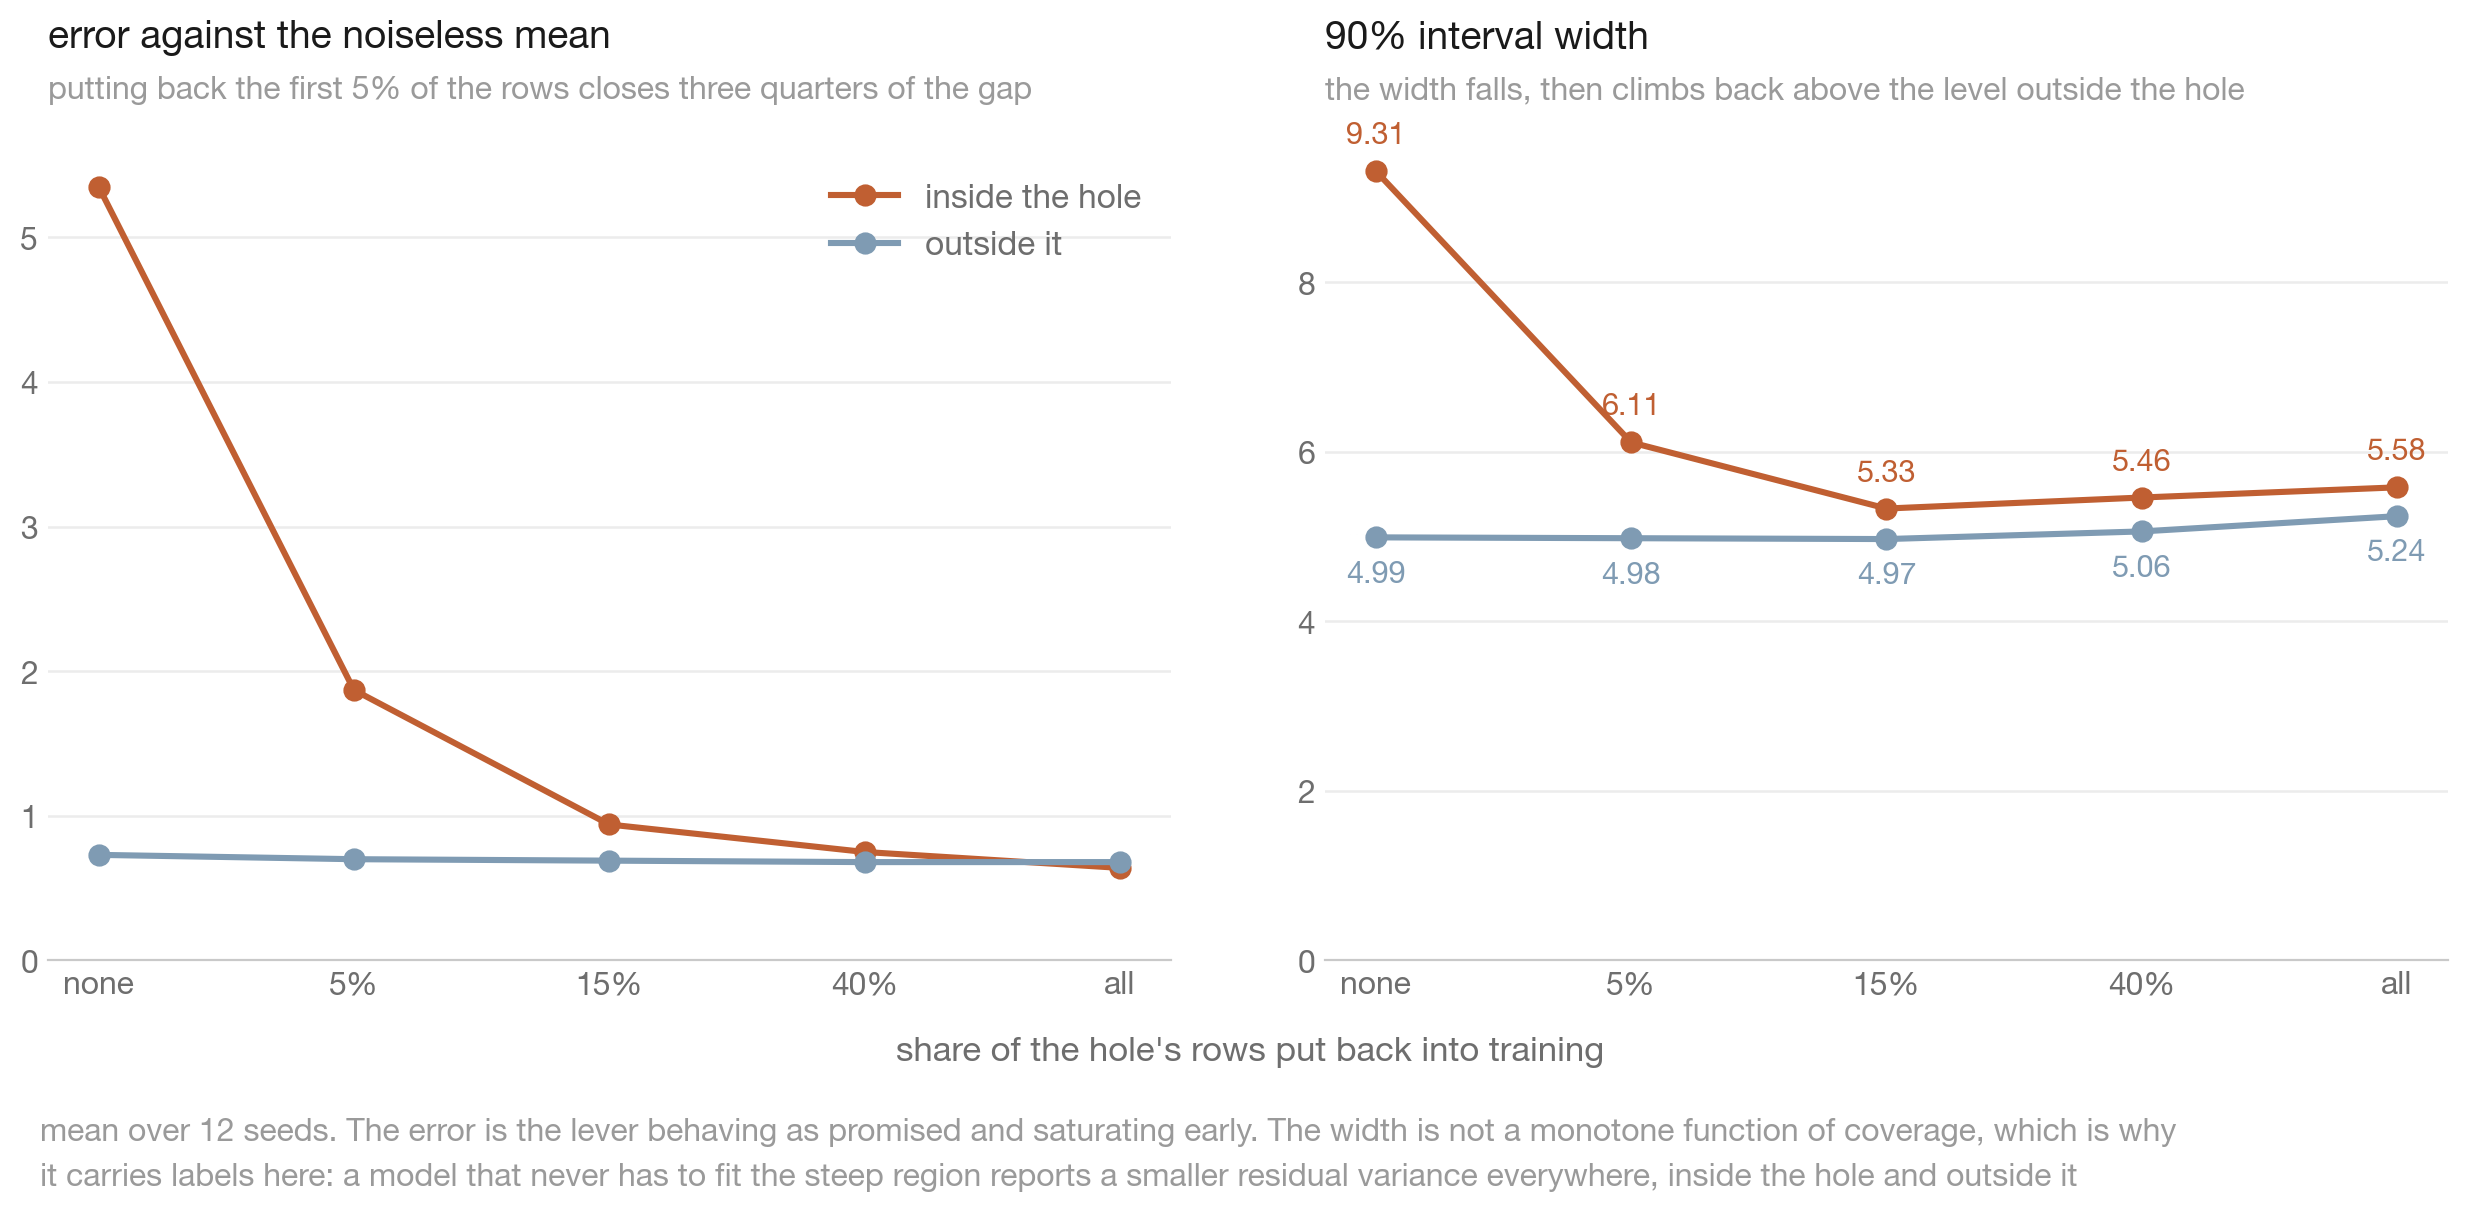

In [11]:
PANELS = [("error against the noiseless mean", "error in the hole", "error outside", False),
          ("90% interval width", "width in the hole", "width outside", True)]
IN_E, OUT_E = "#C05F32", "#7f9bb3"
NOTE = ["putting back the first 5% of the rows closes three quarters of the gap",
        "the width falls, then climbs back above the level outside the hole"]

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.2), dpi=200)
x = np.arange(len(fill))
for ax, (title, a, b, annotate), note in zip(axes, PANELS, NOTE):
    for col, colour, label, dy in ((a, IN_E, "inside the hole", 10), (b, OUT_E, "outside it", -16)):
        ax.plot(x, fill[col], "o-", color=colour, lw=2.2, ms=7, label=label, zorder=3)
        if annotate:
            for xi, v in zip(x, fill[col]):
                ax.annotate(f"{v:.2f}", (xi, v), textcoords="offset points", xytext=(0, dy),
                            ha="center", fontsize=11, color=colour, zorder=4)
    ax.set_title(title, fontsize=14, color=INK, pad=38, loc="left")
    ax.text(0, 1.06, note, transform=ax.transAxes, fontsize=11.5, color=TEXT_FAINT, va="bottom")
    ax.set_xticks(x)
    ax.set_xticklabels(["none", "5%", "15%", "40%", "all"])
    ax.set_ylim(0, None)
    ax.grid(axis="y", color="#ececec", lw=0.9, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c9c9c9")
    ax.tick_params(length=0, labelsize=11.5, colors=TEXT_MUTED)
axes[0].legend(frameon=False, fontsize=12, labelcolor=TEXT_MUTED, loc="upper right")
fig.text(0.5, -0.03, "share of the hole's rows put back into training", ha="center",
         fontsize=12.5, color=TEXT_MUTED)
fig.text(0.02, -0.12,
         f"mean over {N_SEEDS} seeds. The error is the lever behaving as promised and saturating "
         f"early. The width is not a monotone function of coverage, which is why\nit carries "
         f"labels here: a model that never has to fit the steep region reports a smaller residual "
         f"variance everywhere, inside the hole and outside it",
         ha="left", va="center", fontsize=11.5, color=TEXT_FAINT, linespacing=1.7)
fig.tight_layout()
fig.savefig("uncertainty_fill_sweep.png", facecolor="white", bbox_inches="tight")
plt.show()

Two things happen and only one of them is the one people expect.

The error inside the hole falls by a factor of eight, and it does most of that early: putting back
the first 5% of the hole's rows recovers three quarters of the gap, and 15% recovers 94% of it.
Coverage is worth a great deal at the start and very little after.

The width is less obedient. It drops from 9.3 to 5.3 as the first rows return, then drifts back up
to 5.6 at full coverage, slightly above the width outside the hole. That is not a failure. With the
hole cut out the model never has to fit the steep part of the mean function, so it reports a smaller
residual variance everywhere, which is why the width outside rises too. Put those rows back and the
job gets harder and the reported width rises to match. The excess width caused by thin coverage does
go away; what is left is the width the region genuinely deserves.

So the lever is real, it saturates quickly, and it does not take the width to zero. Worth knowing
before promising anyone that more data will narrow an interval.

## When the driver is not in the data

The two causes so far are both visible to the model: `x_noise` is a column it has, and `x_gap` is a
column whose coverage it can be short of. There is a third case that neither section touches. The
thing that drives the spread is not recorded at all — two rows match on every field you store and
one of them is still twice the work.

That case needs no new design. `x_noise` already drives the spread and `x_dup` is already a noisy
copy of it, so withholding columns from the model turns one into the other:

- hide `x_noise` and keep `x_dup`: the driver is unobserved, but a correlated proxy survives
- hide both: the driver is unobserved and nothing left in the data stands in for it

Same rows, same seeds, same model. The only change is which columns it is allowed to see.

In [12]:
hidden_rows, hidden_shares = [], []
for s in SEEDS:
    Xtr, ytr, Xte, sigma = train_test(s)
    for label, drop in HIDE.items():
        tr, te = Xtr.drop(columns=drop), Xte.drop(columns=drop)
        out = fit_uncertainty(tr, ytr, te, s)
        width = 2 * Z90 * np.sqrt(out[:, 1] + out[:, 2])
        dist = NearestNeighbors(n_neighbors=1).fit(tr).kneighbors(te)[0][:, 0]
        err = np.abs(mean_of(te).values - out[:, 0])
        hidden_rows.append({"hidden": label, "seed": s,
                            **signal(out, width, dist, sigma, err)})
        hidden_shares.append({"hidden": label, "seed": s, **surrogate(te, width, s).to_dict()})
    print(f"seed {s} done", flush=True)

# the baseline row is the run above, not a refit
base = attr_df[attr_df.target == WIDTH].drop(columns="target").assign(hidden=NOTHING)
signal_df = pd.concat([pd.DataFrame(signal_rows), pd.DataFrame(hidden_rows)], ignore_index=True)
hidden_share_df = pd.concat([base, pd.DataFrame(hidden_shares)], ignore_index=True)

seed 0 done


seed 1 done


seed 2 done


seed 3 done


seed 4 done


...

seed 7 done


seed 8 done


seed 9 done


seed 10 done


seed 11 done


In [13]:
ROWS = [NOTHING] + list(HIDE)
cols = [c for c in signal_df.columns if c not in ("hidden", "seed")]
print(signal_df.groupby("hidden", sort=False)[cols].mean().loc[ROWS].round(3).to_string())
print()
print("attribution of the interval width, share of total |SHAP|, %:")
hidden_share = hidden_share_df.groupby("hidden", sort=False)[FEATURES].mean().loc[ROWS]
print(hidden_share.round(1).to_string())
print()
print("for comparison, dropping those columns from the baseline and renormalising, with no")
print("change in behaviour at all, would give:")
kept = {label: hidden_share.loc[NOTHING].drop(drop) for label, drop in HIDE.items()}
renorm = pd.DataFrame({k: 100 * v / v.sum() for k, v in kept.items()}).T.reindex(columns=FEATURES)
print(renorm.round(1).to_string())

                               mean error  width mean  width sd  data over knowledge variance  width vs true sigma  distance vs true sigma
hidden                                                                                                                                    
nothing hidden                      1.667       5.860     3.463                       737.199                0.713                  -0.007
x_noise hidden, its copy kept       1.672       6.185     3.749                       805.396                0.734                  -0.005
both hidden, no proxy left          1.614       7.423     2.777                      1184.829               -0.001                  -0.002

attribution of the interval width, share of total |SHAP|, %:
                               x_mean1  x_mean2  x_noise  x_dup  x_gap  x_inert
hidden                                                                         
nothing hidden                     7.6      7.5     35.3   13.3   28.8      7.6
x_n

Read the two tables together.

Read the shares against the renormalised baseline, not against the first row. Dropping a column
inflates every surviving share arithmetically, and that alone accounts for part of every rise.

Hiding the driver but leaving its copy costs the model nothing: the width still tracks the real
noise about as well as before. What changes is the answer you get. Renormalisation alone would put
`x_dup` at about 21%; it comes out at 48%, the largest share in the row, awarded to a feature that
enters the target nowhere. The attribution is right about what predicts the spread and wrong about
what causes it, and it gives no sign of the difference.

Hiding both is the case worth remembering. The average interval gets wider, which is honest — the
variance is still there and the model has nowhere to put it. But the row-to-row pattern, which is
the only thing an attribution consumes, stops tracking the truth: the correlation goes to zero. The
width still varies, the surrogate still fits it, and a confident ranking still comes out. Against
the renormalised baseline that ranking has also gone flatter than the arithmetic predicts, `x_gap`
landing below its renormalised share and the three features that drive nothing landing above theirs,
which is what an unexplainable width looks like.

The nearest-neighbour distance is unmoved throughout, and correctly so: it answers whether there
are rows like this one, which was never the same question as whether the columns explain the
spread.

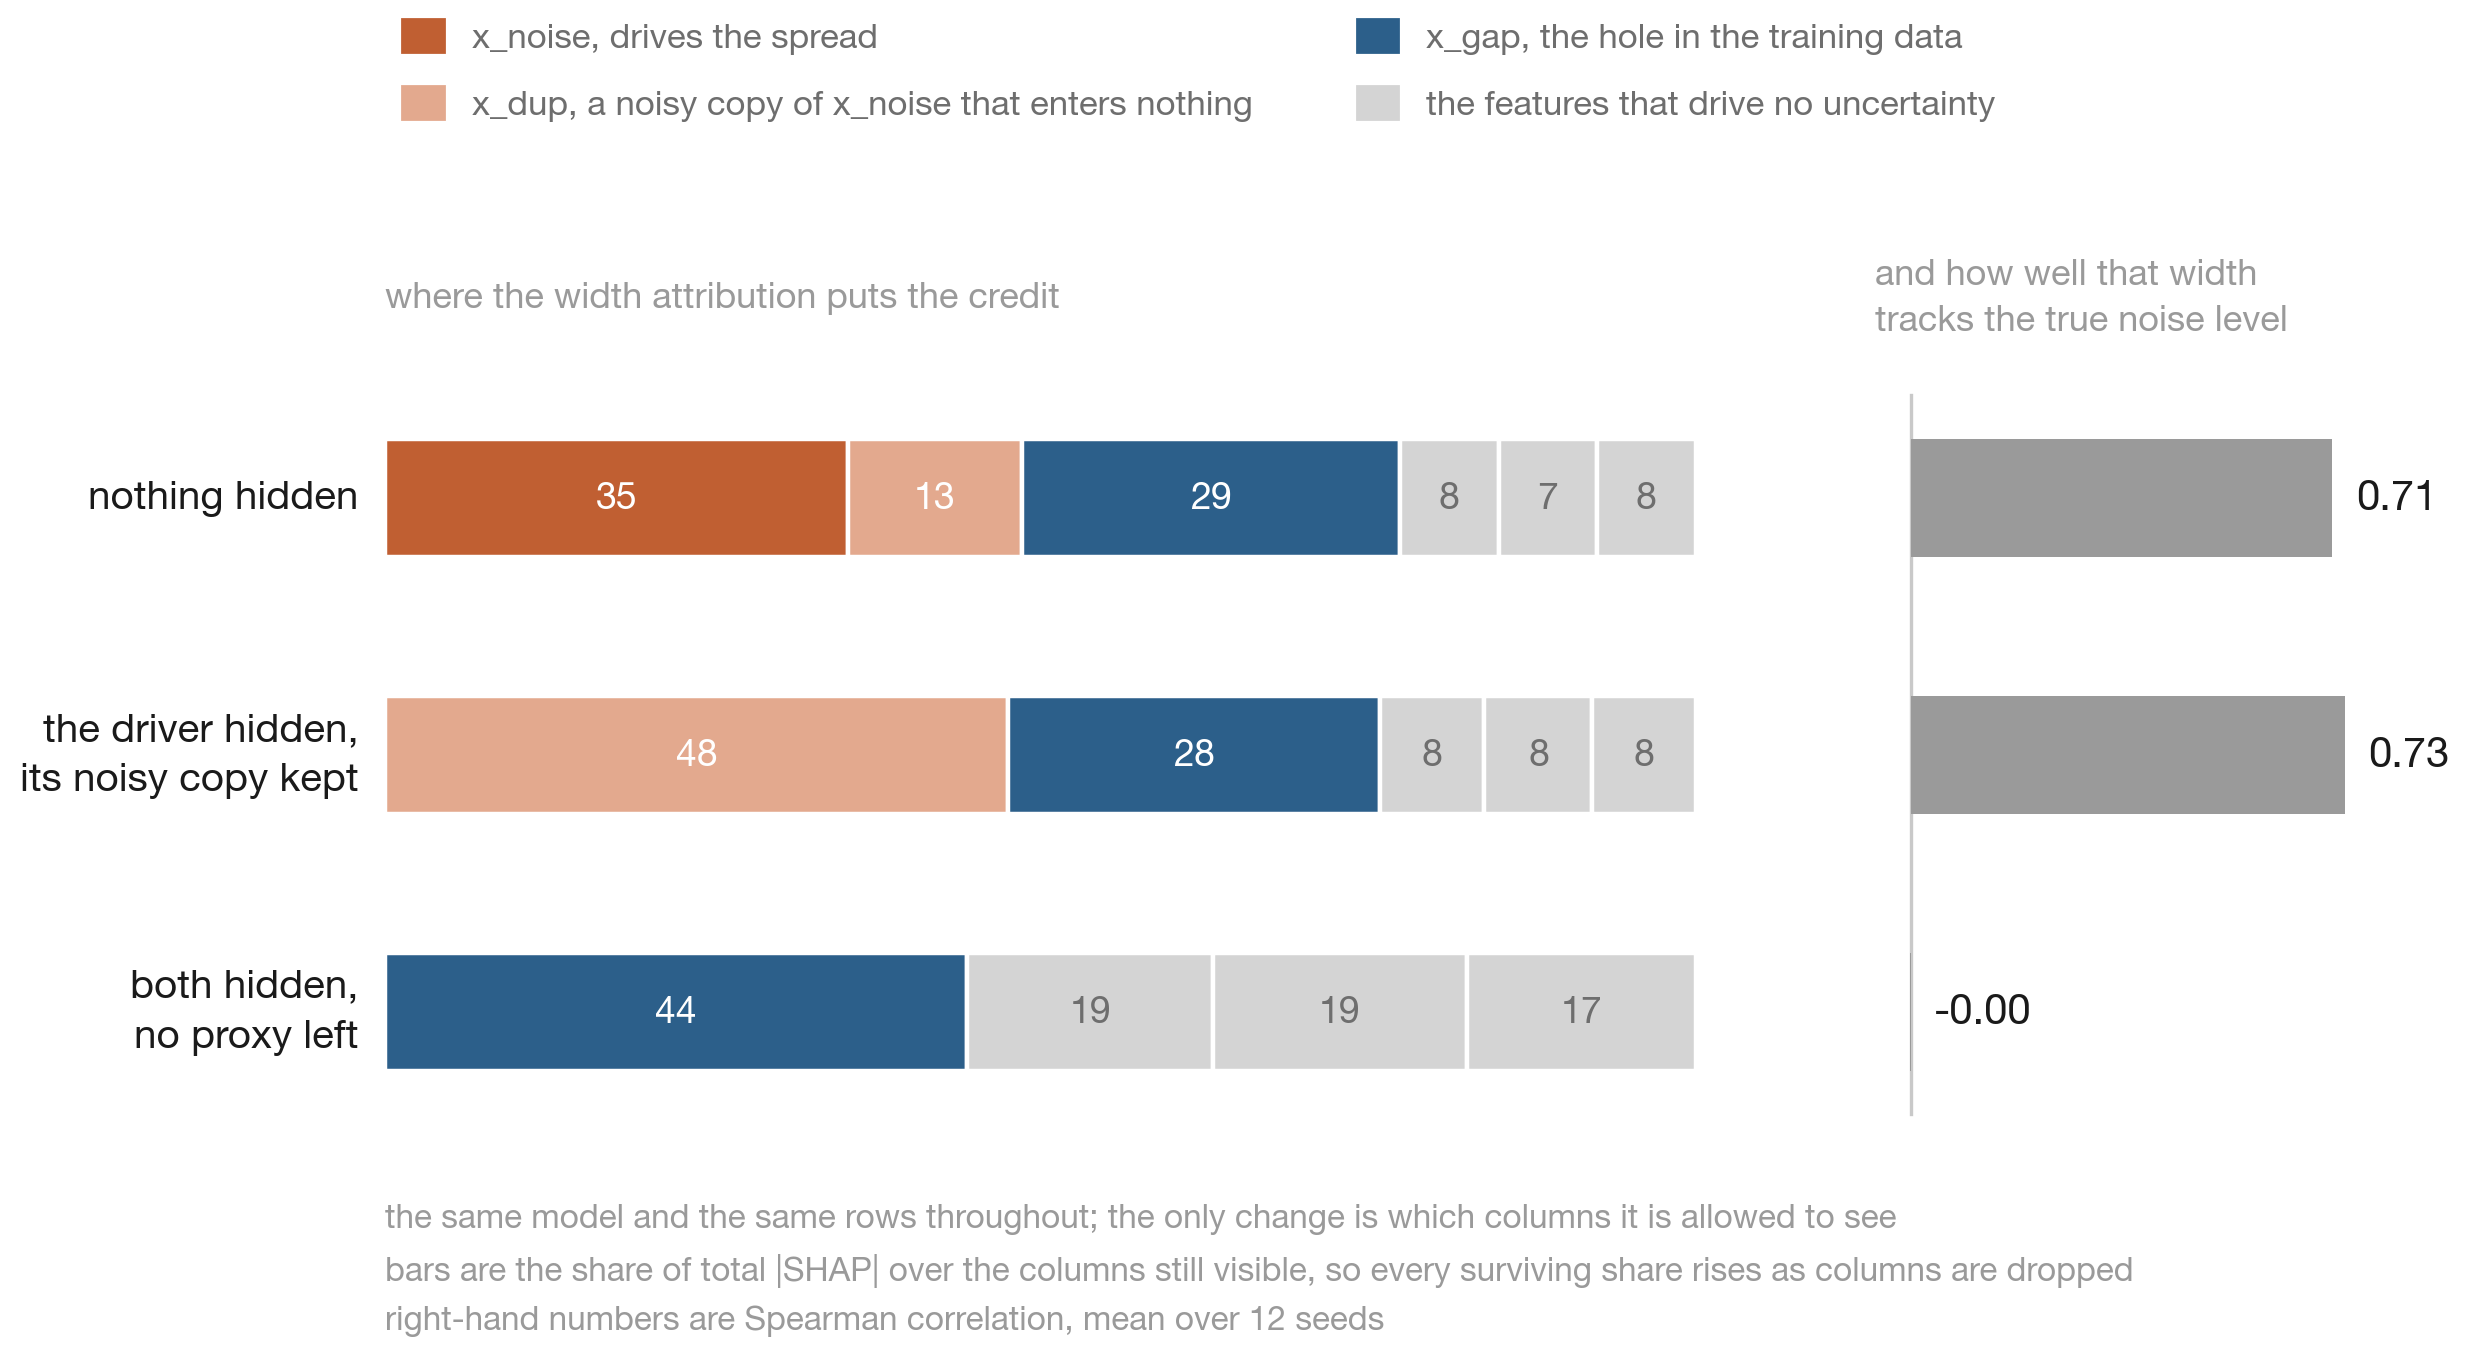

In [14]:
ROW_LABEL = {NOTHING: "nothing hidden",
             "x_noise hidden, its copy kept": "the driver hidden,\nits noisy copy kept",
             "both hidden, no proxy left": "both hidden,\nno proxy left"}
hidden_corr = signal_df.groupby("hidden", sort=False)["width vs true sigma"].mean().loc[ROWS]

fig = plt.figure(figsize=(13.8, 7.2), dpi=200)
left = fig.add_axes([0.215, 0.145, 0.475, 0.535])
right = fig.add_axes([0.755, 0.145, 0.195, 0.535])
for ax in (left, right):
    ax.set_ylim(len(ROWS) - 0.5, -0.5)
    ax.axis("off")

left.set_xlim(0, 100)
for i, r in enumerate(ROWS):
    start = 0.0
    for f in ORDER:
        w = hidden_share.loc[r, f]
        if np.isnan(w):
            continue
        left.barh(i, w, left=start, height=0.46, color=COLOUR.get(f, GREY_E),
                  edgecolor="white", linewidth=1.6, zorder=2)
        if w >= 5:
            left.text(start + w / 2, i, f"{w:.0f}", ha="center", va="center", fontsize=13.5,
                      color="white" if f in COLOUR else TEXT_MUTED, zorder=3)
        start += w
    left.text(-2.0, i, ROW_LABEL.get(r, r), ha="right", va="center", fontsize=14.5, color=INK,
              linespacing=1.5)
left.text(0, -0.78, "where the width attribution puts the credit", ha="left", va="center",
          fontsize=13, color=TEXT_FAINT)

right.set_xlim(-0.06, 0.85)
right.add_line(plt.Line2D([0, 0], [-0.4, len(ROWS) - 0.6], color="#c9c9c9", lw=1.2, zorder=1))
for i, r in enumerate(ROWS):
    v = hidden_corr.loc[r]
    right.barh(i, v, height=0.46, color="#9a9a9a", zorder=2)
    right.text(v + 0.04, i, f"{v:.2f}", ha="left", va="center", fontsize=15, color=INK)
right.text(-0.06, -0.78, "and how well that width\ntracks the true noise level",
           ha="left", va="center", fontsize=13, color=TEXT_FAINT, linespacing=1.5)

left.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c, _ in LEGEND],
            [t for _, t in LEGEND], ncol=2, loc="lower left", bbox_to_anchor=(0, 1.30),
            frameon=False, fontsize=12.5, labelcolor=TEXT_MUTED, handlelength=1.2,
            handleheight=1.1, columnspacing=3.0, labelspacing=0.9, borderpad=0)
fig.text(0.215, 0.055,
         "the same model and the same rows throughout; the only change is which columns it is "
         "allowed to see\nbars are the share of total |SHAP| over the columns still visible, so "
         "every surviving share rises as columns are dropped\nright-hand numbers are Spearman "
         f"correlation, mean over {N_SEEDS} seeds",
         ha="left", va="center", fontsize=12, color=TEXT_FAINT, linespacing=1.7)
fig.savefig("uncertainty_hidden_cause.png", facecolor="white")
plt.show()

## Takeaway

Attributing the interval width does rank both real sources above the three features that drive no
uncertainty, and that is the useful part of the answer.

It does not separate the two sources. The interval width row and the data uncertainty row are the
same list to within a fifth of a point, because the data variance dominates the sum under the square
root — so attributing the width is attributing the noise. Reading the knowledge column instead does
not fix that: `x_noise` still leads it, and `x_gap`, the one feature more data would help with, gets
less credit there than the width already gave it. It is also not stable: the rank table above shows
`x_gap` trading places with `x_noise`, and on some seeds falling behind `x_dup`.

The credit given to `x_dup` is the clearest limit. It enters the target nowhere, and attributing
the true noise function, the one case where the correct answer is not in doubt, still hands it a
quarter of the total. That is Shapley with dependent features rather than anything the model did
wrong, and no amount of care in fitting the surrogate removes it.

Distance to the nearest training row answers the narrower question cleanly, because it is a
statement about the training set rather than about the target. If what you need to know is whether
there are rows like this one, measure that instead of explaining the width.

None of it reaches the case where the cause is not recorded at all. Withholding the driver shows
why. With a correlated column still in the data the attribution names that column instead,
confidently and wrongly. With nothing left to stand in for it the width goes on varying and the
surrogate goes on producing a ranking, while the correlation between that width and the real noise
level is zero. The distance flags neither case, because a row can sit in the middle of the training
data and still be driven by something nobody wrote down.

So there are three questions and this notebook answers two. Which of your columns predict the
spread: attribute the width. Whether there are rows like this one: measure the distance, and expect
the lever behind it to saturate fast and leave a floor. Whether something outside your columns is
driving it: nothing here detects that, and the output looks the same either way.